Saving sales_data(1).csv to sales_data(1).csv

Original Dataset
         Date Customer_ID     Product     Category    Sales  Quantity  \
0  2026-01-01        C001      Laptop  Electronics  55000.0         1   
1  2026-01-02        C002       Phone  Electronics  25000.0         1   
2  2026-01-03        C003  Headphones  Accessories   1500.0         2   
3  2026-01-04        C004    Keyboard  Accessories   1200.0         1   
4  2026-01-05        C005       Mouse  Accessories    800.0         2   

         City  
0     Chennai  
1  Coimbatore  
2     Madurai  
3       Salem  
4      Trichy  

Missing Values:
Date           0
Customer_ID    0
Product        0
Category       0
Sales          1
Quantity       0
City           0
dtype: int64

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null

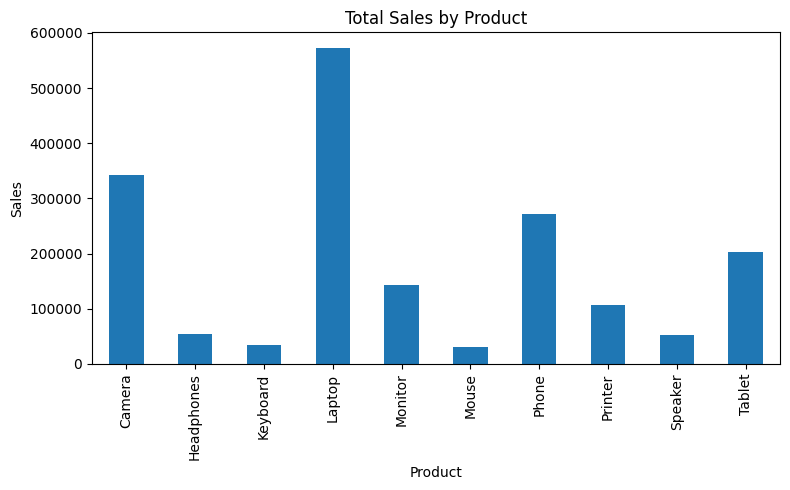

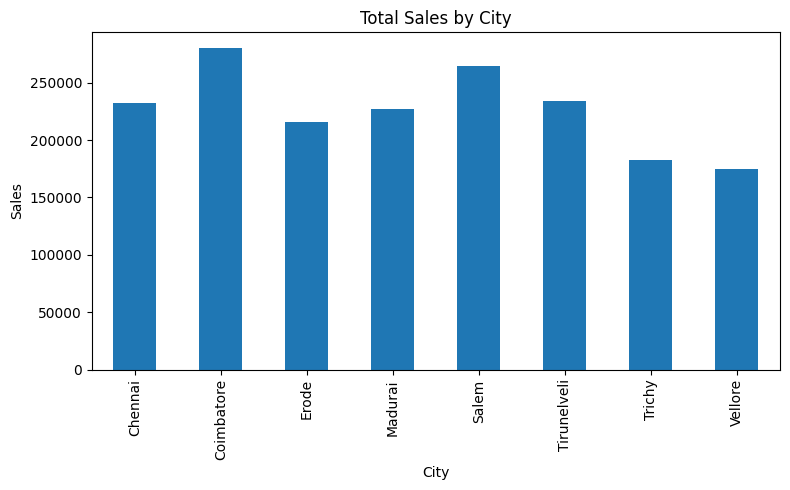

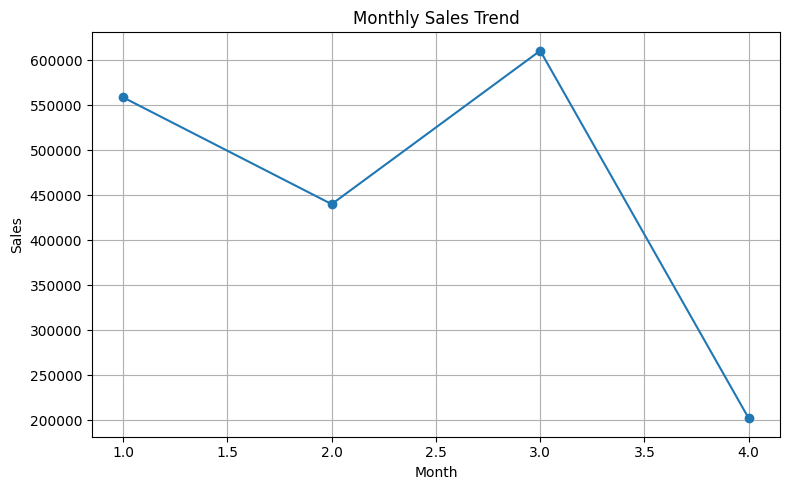


Top 5 Products
Product
Laptop     572500.0
Camera     342500.0
Phone      272500.0
Tablet     202500.0
Monitor    142500.0
Name: Sales, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Project Completed Successfully!


In [4]:
!pip install openpyxl -q

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nOriginal Dataset")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

if "Sales" in df.columns:
    df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

df = df.drop_duplicates()

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])

text_columns = ["Product", "Category", "City"]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe(include="all"))

cleaned_file = "cleaned_sales_data.csv"
df.to_csv(cleaned_file, index=False)

summary = df.describe(include="all")
summary_file = "summary_report.csv"
summary.to_csv(summary_file)

if "Product" in df.columns and "Sales" in df.columns:
    sales_product = df.groupby("Product")["Sales"].sum()

    plt.figure(figsize=(8,5))
    sales_product.plot(kind="bar")
    plt.title("Total Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.savefig("sales_by_product.png")
    plt.show()

if "City" in df.columns and "Sales" in df.columns:
    sales_city = df.groupby("City")["Sales"].sum()

    plt.figure(figsize=(8,5))
    sales_city.plot(kind="bar")
    plt.title("Total Sales by City")
    plt.xlabel("City")
    plt.ylabel("Sales")
    plt.tight_layout()
    plt.savefig("sales_by_city.png")
    plt.show()

if "Date" in df.columns and "Sales" in df.columns:
    df["Month"] = df["Date"].dt.month
    monthly_sales = df.groupby("Month")["Sales"].sum()

    plt.figure(figsize=(8,5))
    monthly_sales.plot(kind="line", marker="o")
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("monthly_sales_trend.png")
    plt.show()

if "Product" in df.columns and "Sales" in df.columns:
    print("\nTop 5 Products")
    print(df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head())

files.download(cleaned_file)
files.download(summary_file)

import os

for image in [
    "sales_by_product.png",
    "sales_by_city.png",
    "monthly_sales_trend.png"
]:
    if os.path.exists(image):
        files.download(image)

print("\nProject Completed Successfully!")